## MLP from Scratch: Used Car Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error, r2_score


np.random.seed(42)

In [2]:
df = pd.read_csv('used_cars_cleaned.csv')
print(df.shape)
df.head()

(1451970, 46)


,back_legroom,body_type,city,city_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,exterior_color,fleet,...,seller_rating,theft_title,torque,transmission,trim_name,wheel_system,wheelbase,width,year,age
0,33.8,SUV / Crossover,San Juan,NaN,510,4.0,2000.0,I4,Blanco,0.0,...,3.000000,0.0,295.0,A,P300 R-Dynamic SE AWD,AWD,105.6,82.7,2020,0
1,NaN,Coupe,Guaynabo,NaN,1252,4.0,1700.0,I4,Red,0.0,...,NaN,0.0,258.0,A,Launch Edition Coupe RWD,RWD,93.7,73.5,2015,5
2,35.1,Sedan,Guaynabo,22.0,1233,6.0,3000.0,I6,Silver,0.0,...,NaN,0.0,330.0,A,340i xDrive Sedan AWD,AWD,110.6,80.0,2016,4
3,35.7,Sedan,Bay Shore,NaN,33,4.0,1600.0,I4,Phantom Black,0.0,...,3.447761,0.0,195.0,A,Sport Sedan FWD,FWD,106.3,70.9,2017,3
4,38.1,Sedan,Bay Shore,27.0,55,4.0,1500.0,I4,Silver Ice Metallic,1.0,...,3.447761,0.0,184.0,A,LT FWD,FWD,111.4,73.0,2018,2


In [3]:
# group features by type so we can handle each differently

numeric = ['year', 'mileage', 'horsepower', 'torque', 'engine_displacement',
           'engine_cylinders', 'fuel_tank_volume', 'city_fuel_economy',
           'highway_fuel_economy', 'owner_count', 'daysonmarket', 'age']

low_cat  = ['body_type', 'fuel_type', 'transmission', 'wheel_system']
high_cat = ['make_name', 'model_name']
binary   = ['has_accidents', 'frame_damaged', 'salvage', 'franchise_dealer']

# drop rows where price is missing since thats our target
df = df.dropna(subset=['price'])

In [4]:
# full missing values based on column type

for col in numeric:
    df[col] = df[col].fillna(df[col].median())
for col in binary:
    df[col] = df[col].fillna(0)
for col in low_cat:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in high_cat:
    df[col] = df[col].fillna('Unknown')

In [5]:
#split into training + test 80/20
train_size = int(.8 * len(df))
train = df[:train_size]
test = df[train_size:]
print(len(train), len(test))

1161576 290394


In [6]:
# replace make and model with the average price of that make/model
for col in high_cat:
    avg_price = train.groupby(col)['price'].mean().to_dict()
    train[col] = train[col].map(avg_price)
    test[col] = test[col].map(avg_price).fillna(train['price'].mean())

train_ohe = pd.get_dummies(train[low_cat], drop_first=True)
test_ohe = pd.get_dummies(test[low_cat], drop_first=True)

test_ohe = test_ohe.reindex(columns=train_ohe.columns, fill_value=0)

/var/folders/dd/5hhztzc96t1717zrjlkk8nsh0000gn/T/ipykernel_68745/2813213630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[col] = train[col].map(avg_price)
/var/folders/dd/5hhztzc96t1717zrjlkk8nsh0000gn/T/ipykernel_68745/2813213630.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[col] = test[col].map(avg_price).fillna(train['price'].mean())
/var/folders/dd/5hhztzc96t1717zrjlkk8nsh0000gn/T/ipykernel_68745/2813213630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [7]:
#combine features into one matrix
X_train = np.hstack([
    train[numeric].values,
    train[binary].values.astype(float),
    train[high_cat].values,
    train_ohe.values.astype(float)
])
X_test = np.hstack([
    test[numeric].values,
    test[binary].values.astype(float),
    test[high_cat].values,
    test_ohe.values.astype(float)
])

y_train = train['price'].values.reshape(-1, 1)
y_test = test['price'].values.reshape(-1, 1)

#scale it
scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

print(X_train.shape)

(1161576, 40)


In [8]:
n, d = X_train.shape
q = 64 #num hidden nodes

W1 = np.random.randn(d, q) * np.sqrt(2 / d)
W2 = np.random.randn(q, 1) * np.sqrt(2 / q)

print(W1.shape, W2.shape)

(40, 64) (64, 1)


In [9]:
def f(x):
    h = np.maximum(0, x.dot(W1))
    return h.dot(W2)

In [10]:
eta = 1e-3
epochs = 60
batch_size = 1024
n = X_train.shape[0]

errors = []

for epoch in range(1, epochs + 1):
    idx = np.random.permutation(n)
    X_shuf = X_train[idx]
    y_shuf = y_train[idx]

    for i in range(0, n, batch_size):
        X_b = X_shuf[i:i+batch_size]
        y_b = y_shuf[i:i+batch_size]
        nb  = X_b.shape[0]

        # forward pass

        h   = np.maximum(0, X_b.dot(W1))
        out = h.dot(W2)

        # backprop

        dW2 = (2/nb) * h.T.dot(out - y_b)

        dh  = (out - y_b).dot(W2.T)
        dW1 = (2/nb) * X_b.T.dot(dh * np.heaviside(X_b.dot(W1), 0))

        # update weights

        W1 = W1 - eta * dW1
        W2 = W2 - eta * dW2

    e = (1/n) * np.sum((f(X_train) - y_train) ** 2)
    errors.append(e)

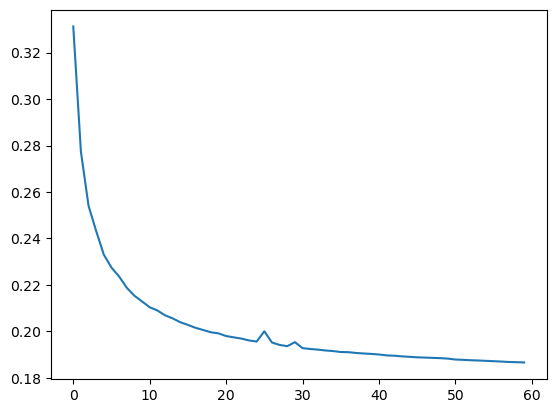

In [11]:
plt.plot(range(epochs), errors, label='line')
plt.show()

In [12]:
preds   = y_scaler.inverse_transform(f(X_test)).flatten()
actuals = y_scaler.inverse_transform(y_test).flatten()

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(np.mean((actuals - preds) ** 2))
r2   = r2_score(actuals, preds)

print(mae)
print(rmse)
print (r2)

3507.702049107294
11214.514592181338
0.6951416042442713


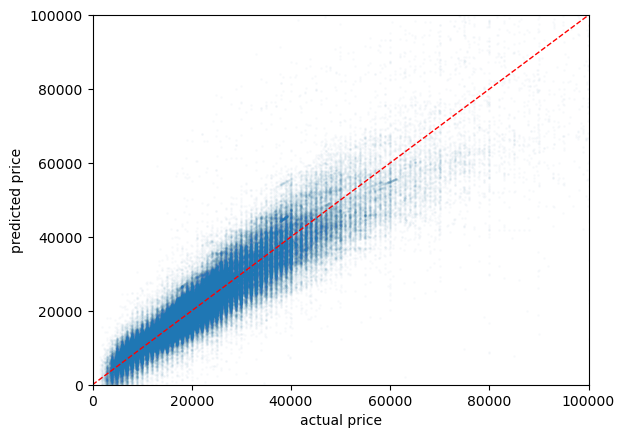

In [13]:
plt.scatter(actuals, preds, alpha=0.02, s=1)
plt.plot([0, 100000], [0, 100000], 'r--', lw=1)
plt.xlim(0, 100000)
plt.ylim(0, 100000)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.show()

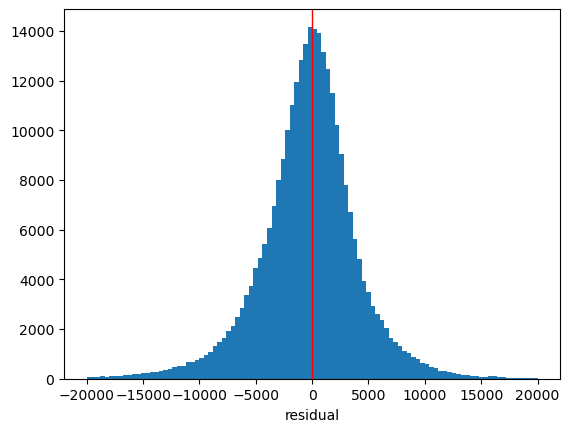

In [14]:
residuals = preds - actuals
plt.hist(residuals, bins=100, range=(-20000, 20000))
plt.axvline(0, color='red', lw=1)
plt.xlabel('residual')
plt.show()